## Raport 1
### Komputerowe symulacje procesów stochastycznych

Autorzy
* Krzysztof Dobrzański (242504)
* Bartosz Michalak (268429)

In [284]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import scipy.stats as stats
import seaborn as sns
from tqdm import tqdm # progress bar
import math

np.random.seed(42)

In [285]:
def get_random_a_stable(alpha, beta, gamma, delta):
    theta = np.random.uniform()*math.pi - math.pi/2
    theta_0 = np.arctan(beta*np.tan(math.pi*alpha/2))/alpha
    W = np.random.exponential()

    if alpha == 1:
        Z = 2/math.pi * ( (math.pi/2 + beta*theta)*np.tan(theta) - beta*np.log((math.pi/2 * W*np.cos(theta)) / (math.pi/2 + beta*theta)) )
        return gamma*Z + (delta + beta * 2/math.pi * gamma * np.log(gamma))
    else:
        Z = np.sin(alpha*(theta_0 + theta)) / ((np.cos(alpha*theta_0)*np.cos(theta))**(1/alpha)) * ( np.cos(alpha*theta_0 + (alpha - 1)*theta) / W )**((1 - alpha)/alpha)
        return gamma*Z + delta

In [286]:
def estimate_alpha_ecdf(t, tail_fraction=0.05):
    if len(t[t > 0]) < 10:
        t = np.array([-v for v in t])
        
    t = np.sort(t)
    t_pos = t[t > 0]
    if len(t_pos) < 2: return np.nan
    n_tail = min(len(t_pos), int(len(t) * tail_fraction))
    if n_tail < 2: return np.nan
    
    top_t = t_pos[-n_tail:]
    ecdf_weights = np.arange(n_tail, 0, -1) / len(t)
    lnt = np.log(top_t)
    lnfdce = np.log(ecdf_weights)
    slope, _, _, _, _ = linregress(lnt, lnfdce)
    return np.clip(-slope, 0.0, 2.0)

Funkcja ta wykorzystywana jest później do analizy estymacji w zależnościod m.in. parametrów `beta` oraz `delta`. Odpowiedni dobór tych parametrów (np. `beta` bliskie -1 lub bardzo małe `delta`) spowodować mogą, że cała próba losowa będzie ujemna. Z tego powodu zdecydowliśmy się na następujące modyfikacje podstawowej implementacji estymatora **ECDF**:
* dla zbyt małej ilości danych dodatnich (tu arbitralnie wybrane 10 punktów), cała próba jest symetrycznie obracana wokół 0. Powoduje to, że analizowany jest lewy, a nie prawy ogon,
* do analizy ogona użyliśmy 5% wszystkich skrajnych wartości (zamiast np. 5% skrajnych wartości pozytywnych).

Dodatkowo, ograniczyliśmy wyniki do wartości 2. Estymator **ECDF** cechuje się zawyżaniem wartości i bardxzo często generował estymaty wychodzące poza dziedzinę parametru `alpha`.

In [287]:
def estimate_alpha_cf(X, t_max=1.0, num_t=50):
    t_vals = np.linspace(0.01, t_max, num_t)
    phi_n_abs = np.array([np.abs(np.mean(np.exp(1j * t * X))) for t in t_vals])
    valid_mask = (phi_n_abs > 0) & (phi_n_abs < 1)
    if not np.any(valid_mask): return np.nan
    
    y = np.log(-np.log(phi_n_abs[valid_mask]))
    x = np.log(t_vals[valid_mask])
    slope, _, _, _, _ = linregress(x, y)
    return np.clip(slope, 0.0, 2.0)

## Podpunkt (i)

Prawdziwa alpha:	 1.5
Estymata ECDF:		 1.627
Estymata CF:		 1.650


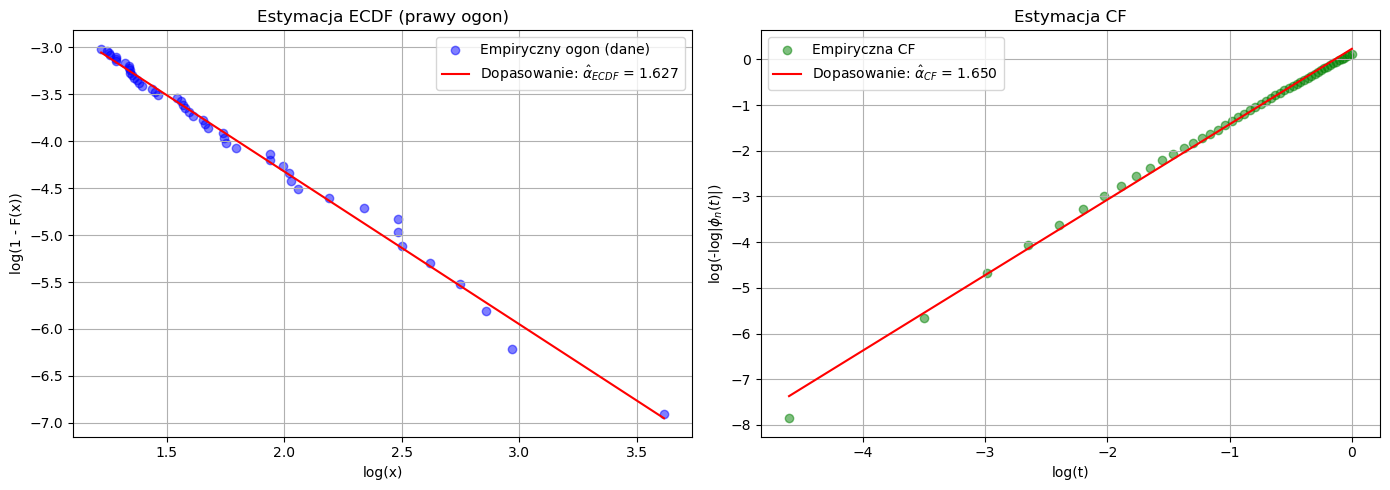

In [288]:
true_alpha = 1.5
beta = 0.0
gamma = 1.0
delta = 0.0
sample_count = 1000

x_samples = np.array([get_random_a_stable(true_alpha, beta, gamma, delta) for _ in range(0, sample_count)])

alpha_ecdf = estimate_alpha_ecdf(x_samples)
alpha_cf = estimate_alpha_cf(x_samples)

print(f"Prawdziwa alpha:\t {true_alpha}")
print(f"Estymata ECDF:\t\t {alpha_ecdf:.3f}")
print(f"Estymata CF:\t\t {alpha_cf:.3f}")

plt.figure(figsize=(14, 5))

###############################
# ECDF plot
###############################

plt.subplot(1, 2, 1)
X_sorted = np.sort(x_samples)
X_pos = X_sorted[X_sorted > 0]
tail_frac = 0.1
n_tail = int(len(X_pos) * tail_frac)
X_tail = X_pos[-n_tail:]
surv_probs = np.arange(n_tail, 0, -1) / len(X_sorted)

log_x = np.log(X_tail)
log_y = np.log(surv_probs)


plt.scatter(log_x, log_y, color='blue', alpha=0.5, label='Empiryczny ogon (dane)')

fit_y = -alpha_ecdf * log_x + (log_y.mean() - (-alpha_ecdf * log_x.mean()))
plt.plot(log_x, fit_y, color='red', label=f'Dopasowanie: $\\hat{{\\alpha}}_{{ECDF}}$ = {alpha_ecdf:.3f}')
plt.xlabel('log(x)')
plt.ylabel('log(1 - F(x))')
plt.title('Estymacja ECDF')
plt.legend()
plt.grid(True)

###############################
# CF plot
###############################

plt.subplot(1, 2, 2)
t_vals = np.linspace(0.01, 1.0, 50)
phi_n_abs = np.array([np.abs(np.mean(np.exp(1j * t * x_samples))) for t in t_vals])
valid = (phi_n_abs > 0) & (phi_n_abs < 1)
log_t = np.log(t_vals[valid])
log_neg_log_phi = np.log(-np.log(phi_n_abs[valid]))

plt.scatter(log_t, log_neg_log_phi, color='green', alpha=0.5, label='Empiryczna CF')
fit_y_cf = alpha_cf * log_t + (log_neg_log_phi.mean() - alpha_cf * log_t.mean())
plt.plot(log_t, fit_y_cf, color='red', label=f'Dopasowanie: $\\hat{{\\alpha}}_{{CF}}$ = {alpha_cf:.3f}')
plt.xlabel('log(t)')
plt.ylabel('log(-log|$\\phi_n(t)$|)')
plt.title('Estymacja CF')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Podpunkt (ii)

Symulacja Monte Carlo: 100%|██████████| 1000/1000 [00:31<00:00, 31.49it/s]


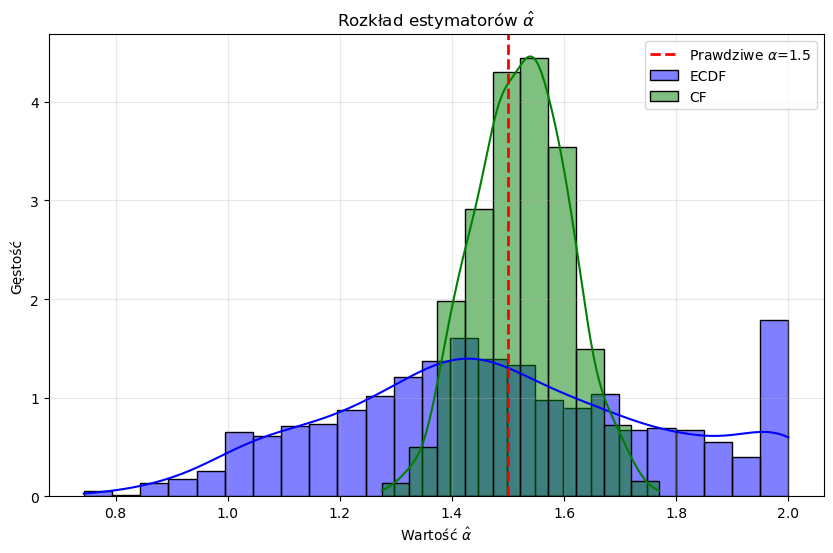

In [293]:
true_alpha = 1.5
beta = 0.0
gamma = 1.0
delta = 0.0
sample_count = 1000

m_iterations = 1000
alpha_ecdf_results = []
alpha_cf_results = []

for _ in tqdm(range(m_iterations), desc="Symulacja Monte Carlo"):
    x_vals = np.array([get_random_a_stable(true_alpha, beta, gamma, delta) for _ in range(0, sample_count)])

    alpha_ecdf_results.append(estimate_alpha_ecdf(x_vals))
    alpha_cf_results.append(estimate_alpha_cf(x_vals))

# Remove NaN values
res_ecdf = np.array(alpha_ecdf_results)[~np.isnan(alpha_ecdf_results)]
res_cf = np.array(alpha_cf_results)[~np.isnan(alpha_cf_results)]

plt.figure(figsize=(10, 6))
sns.histplot(res_ecdf, color='blue', alpha=0.5, label='ECDF', kde=True, stat="density", binwidth=0.05)
sns.histplot(res_cf, color='green', alpha=0.5, label='CF', kde=True, stat="density", binwidth=0.05)
plt.axvline(true_alpha, color='red', linestyle='--', linewidth=2, label=f'Prawdziwe $\\alpha$={true_alpha}')
plt.title(f'Rozkład estymatorów $\\hat{{\\alpha}}$')
plt.xlabel(f'Wartość $\\hat{{\\alpha}}$')
plt.ylabel('Gęstość')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Z otrzmanego wyniku wynika, że metoda estymacji CF jest znacznie dokładniejsza od metody **ECDF** - charakteryzuje się mniejszą wariancją i lepszym dopasowaniem do autentycznej wartości `alpha`.

Estymator **ECDF** ma tendencję do zawyżania wartości. Ponieważ wynik jest ograniczony do 2, powoduje to zawyżenie częstości występowania tej wartości w estymacji. Jest to szczególnie widoczne dla małych rozmiarów próby (parametru `sample_count`). Dzieje się tak, ponieważ mała próba oznacza jeszcze mniejszą liczbę skrajnych wartości w ogonie, co zwiększa wariancję regresji liniowej.

Estymator **CF** jest "bardziej odporny" na niskie rozmiary próby.

## Podpunkt (iii)

### Zależność od alpha i beta, przy gamma = 1 oraz delta = 0

In [294]:
alpha_grid = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]
beta_grid = [-0.95, -0.5, -0.25, 0.0, 0.25, 0.5, 0.95]
gamma = 1.0
delta = 0.0
simulations_per_params = 300
sample_count_per_sim = 1000

mse_ecdf = np.zeros((len(alpha_grid), len(beta_grid)))
mae_ecdf = np.zeros((len(alpha_grid), len(beta_grid)))
mse_cf = np.zeros((len(alpha_grid), len(beta_grid)))
mae_cf = np.zeros((len(alpha_grid), len(beta_grid)))

for i, alpha in enumerate(tqdm(alpha_grid, desc="Liczenie MSE i MAE")):
    for j, beta in enumerate(beta_grid):
        
        est_ecdf = []
        est_cf = []
        
        for _ in range(simulations_per_params):
            x_vals = np.array([get_random_a_stable(alpha, beta, gamma, delta) for _ in range(0, sample_count_per_sim)])
            
            est_ecdf.append(estimate_alpha_ecdf(x_vals))
            est_cf.append(estimate_alpha_cf(x_vals))
            
        est_ecdf = np.array(est_ecdf)[~np.isnan(est_ecdf)]
        est_cf = np.array(est_cf)[~np.isnan(est_cf)]
        
        mse_ecdf[i, j] = np.mean((est_ecdf - a)**2)
        mae_ecdf[i, j] = np.mean(np.abs(est_ecdf - a))
        
        mse_cf[i, j] = np.mean((est_cf - a)**2)
        mae_cf[i, j] = np.mean(np.abs(est_cf - a))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.heatmap(mse_ecdf, annot=True, fmt=".3f", xticklabels=beta_grid, yticklabels=alpha_grid, ax=axes[0,0], cmap='YlOrRd')
axes[0,0].set_title('MSE - Metoda ECDF')
axes[0,0].set_xlabel('$\\beta$')
axes[0,0].set_ylabel('$\\alpha$')

sns.heatmap(mse_cf, annot=True, fmt=".3f", xticklabels=beta_grid, yticklabels=alpha_grid, ax=axes[0,1], cmap='YlOrRd')
axes[0,1].set_title('MSE - Metoda CF')
axes[0,1].set_xlabel('$\\beta$')
axes[0,1].set_ylabel('$\\alpha$')

sns.heatmap(mae_ecdf, annot=True, fmt=".3f", xticklabels=beta_grid, yticklabels=alpha_grid, ax=axes[1,0], cmap='Blues')
axes[1,0].set_title('MAE - Metoda ECDF')
axes[1,0].set_xlabel('$\\beta$')
axes[1,0].set_ylabel('$\\alpha$')

sns.heatmap(mae_cf, annot=True, fmt=".3f", xticklabels=beta_grid, yticklabels=alpha_grid, ax=axes[1,1], cmap='Blues')
axes[1,1].set_title('MAE - Metoda CF')
axes[1,1].set_xlabel('$\\beta$')
axes[1,1].set_ylabel('$\\alpha$')

plt.tight_layout()
plt.show()

Liczenie MSE i MAE:   0%|          | 0/8 [00:00<?, ?it/s]

Liczenie MSE i MAE:  25%|██▌       | 2/8 [03:18<09:54, 99.14s/it]


KeyboardInterrupt: 

Estymator **CF** cechuje się mniejszymi błędami **MSE** oraz **MAE** w przypadku obu estymatorów, wielkości błędów znacząco zwiekszają się wraz ze malejącym parametrem `alpha`. Dla `alpha = 2` (czyli rozkładu normalnego), błędy stają się bardzo małe. W przypadku estymatora **ECDF** jest to dodatkowo spowodowane obcięciem wartości do 2 w połączeniu z tendencją do zawyżania estymat.

Dla estymatora CF, błędy są niezależne od parametru `beta`. W przypadku estymatora **ECDF**, parametr `beta` może wpływać na ilość punktów użytych do regresji liniowej, co może pogarszać estymację.

### Zależność od gamma i delta, przy alpha = 1.5 i beta = 0

In [295]:
alpha = 1.5
beta = 0.0
gamma_grid = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 5.0, 10.0]
delta_grid = [-100.0, -10.0, 0.0, 10.0, 100.0]
simulations_per_params = 200
sample_count_per_sim = 1000

mse_ecdf = np.zeros((len(gamma_grid), len(delta_grid)))
mae_ecdf = np.zeros((len(gamma_grid), len(delta_grid)))
mse_cf = np.zeros((len(gamma_grid), len(delta_grid)))
mae_cf = np.zeros((len(gamma_grid), len(delta_grid)))

for i, gamma in enumerate(tqdm(gamma_grid, desc="Liczenie MSE i MAE")):
    for j, delta in enumerate(delta_grid):
        
        est_ecdf = []
        est_cf = []
        
        for _ in range(simulations_per_params):
            x_vals = np.array([get_random_a_stable(alpha, beta, gamma, delta) for _ in range(0, sample_count_per_sim)])
            
            est_ecdf.append(estimate_alpha_ecdf(x_vals))
            est_cf.append(estimate_alpha_cf(x_vals))
            
        est_ecdf = np.array(est_ecdf)[~np.isnan(est_ecdf)]
        est_cf = np.array(est_cf)[~np.isnan(est_cf)]
        
        mse_ecdf[i, j] = np.mean((est_ecdf - a)**2)
        mae_ecdf[i, j] = np.mean(np.abs(est_ecdf - a))
        
        mse_cf[i, j] = np.mean((est_cf - a)**2)
        mae_cf[i, j] = np.mean(np.abs(est_cf - a))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.heatmap(mse_ecdf, annot=True, fmt=".3f", xticklabels=delta_grid, yticklabels=gamma_grid, ax=axes[0,0], cmap='YlOrRd')
axes[0,0].set_title('MSE - Metoda ECDF')
axes[0,0].set_xlabel('$\\delta$')
axes[0,0].set_ylabel('$\\gamma$')

sns.heatmap(mse_cf, annot=True, fmt=".3f", xticklabels=delta_grid, yticklabels=gamma_grid, ax=axes[0,1], cmap='YlOrRd')
axes[0,1].set_title('MSE - Metoda CF')
axes[0,1].set_xlabel('$\\delta$')
axes[0,1].set_ylabel('$\\gamma$')

sns.heatmap(mae_ecdf, annot=True, fmt=".3f", xticklabels=delta_grid, yticklabels=gamma_grid, ax=axes[1,0], cmap='Blues')
axes[1,0].set_title('MAE - Metoda ECDF')
axes[1,0].set_xlabel('$\\delta$')
axes[1,0].set_ylabel('$\\gamma$')

sns.heatmap(mae_cf, annot=True, fmt=".3f", xticklabels=delta_grid, yticklabels=gamma_grid, ax=axes[1,1], cmap='Blues')
axes[1,1].set_title('MAE - Metoda CF')
axes[1,1].set_xlabel('$\\delta$')
axes[1,1].set_ylabel('$\\gamma$')

plt.tight_layout()
plt.show()

Liczenie MSE i MAE:   0%|          | 0/8 [00:00<?, ?it/s]

W przypadku obu metod, wzrost parametru `gamma` utrudnia dokładną estymację.

Dla metody **CF** parametr `delta` ma wpływu na wynik. W przypadku metody **ECDF**, parametr ten zmienia liczbę punktów dostępnych dla regresji liniowej (podobnie do parametru `beta`). 

## Interpretacja wyników

